<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/logo_dataprojectlab.png" width="220"/>
</div>

# EduTrack Analytics
## Notebook 2 — Data Cleaning & Feature Engineering
### ✅ VERSION CORRIGÉE

> **Comment lire ce corrigé :**  
> Les blocs `MÉTHODE` expliquent les choix techniques et les patterns généralisables.  
> Les blocs `INTERPRÉTATION` lisent les résultats.  
> Les blocs `MÉTIER` font le lien entre le chiffre et la décision business.

| | |
|---|---|
| **Prérequis** | Notebook 1 complété |
| **Niveau** | Intermédiaire |
| **Outils** | Python — pandas, numpy, matplotlib |
| **Durée estimée** | 3h à 4h |

---
> Le Notebook 1 a identifié **6 anomalies** dans les 5 fichiers. Ce notebook les corrige toutes systématiquement, puis construit les variables analytiques clés du projet. La qualité du feature engineering conditionne directement la performance du modèle ML du NB5.

---
## Étape 1 — Imports et chargement

> **MÉTHODE — Pourquoi recharger les CSV depuis zéro ?**
>
> On recharge les 5 CSV depuis zéro pour partir d'un état propre et reproductible. Ne jamais continuer depuis l'état d'un notebook précédent sans recharger — les transformations intermédiaires pourraient avoir modifié les données en mémoire.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, sys

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

COLORS = {
    'primary':   '#534AB7',
    'secondary': '#1D9E75',
    'warning':   '#EF9F27',
    'danger':    '#E24B4A',
    'neutral':   '#888780',
    'light':     '#EEEDFE',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F8',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

# ── Détection Colab / Local ──────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = '/content/drive/MyDrive/DataProjectLab/projects/elearning_analytics/'
else:
    SAVE_PATH = './outputs/'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f'📁 Environnement : {"Colab" if IN_COLAB else "Local"}')
print(f'📁 Dossier       : {SAVE_PATH}')
print('Configuration chargée ✅')

📁 Environnement : Local
📁 Dossier       : ./outputs/
Configuration chargée ✅


In [2]:
BASE_URL = 'https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/elearning_analytics/data/'

df_parc  = pd.read_csv(BASE_URL + 'parcours.csv')
df_app   = pd.read_csv(BASE_URL + 'apprenants.csv',   parse_dates=['date_inscription'])
df_inscr = pd.read_csv(BASE_URL + 'inscriptions.csv', parse_dates=['date_inscription', 'date_fin_reelle'])
df_sess  = pd.read_csv(BASE_URL + 'sessions.csv',     parse_dates=['date_session'])
df_paie  = pd.read_csv(BASE_URL + 'paiements.csv',    parse_dates=['date_paiement'])

DATE_REF = pd.Timestamp('2024-06-30')

print('Chargement OK')
for name, df in [('parcours', df_parc), ('apprenants', df_app),
                  ('inscriptions', df_inscr), ('sessions', df_sess),
                  ('paiements', df_paie)]:
    print(f'  {name:<20} {len(df):>7,} lignes')

Chargement OK
  parcours                  12 lignes
  apprenants             4,500 lignes
  inscriptions           6,460 lignes
  sessions              57,075 lignes
  paiements              8,703 lignes


---
## Étape 2 — Nettoyage : apprenants.csv

### MÉTHODE
On suit un ordre logique :
1. D'abord les doublons (réduire le volume avant les autres opérations)
2. Ensuite les valeurs aberrantes (corriger les incohérences métier)
3. Enfin les valeurs manquantes (imputer ou signaler)

`drop_duplicates(keep='first')` conserve la première occurrence — dans un contexte CRM, la première inscription est généralement la référence.

In [3]:
n_avant = len(df_app)
df_app = df_app.drop_duplicates(subset=['email'], keep='first')
print(f'Doublons email supprimés  : {n_avant - len(df_app)} (avant={n_avant}, après={len(df_app)})')

mediane_age = df_app[(df_app['age'] >= 16) & (df_app['age'] <= 80)]['age'].median()
mask_age    = (df_app['age'] < 16) | (df_app['age'] > 80)
print(f'Âges aberrants corrigés   : {mask_age.sum()} -> remplacé par médiane ({mediane_age:.0f} ans)')
df_app.loc[mask_age, 'age'] = int(mediane_age)

n_pays_null = df_app['pays'].isnull().sum()
df_app['pays'] = df_app['pays'].fillna('Non renseigné')
print(f'Pays null remplis         : {n_pays_null}')
print(f'\nApprenants après nettoyage : {len(df_app):,}')

Doublons email supprimés  : 3 (avant=4500, après=4497)
Âges aberrants corrigés   : 5 -> remplacé par médiane (27 ans)
Pays null remplis         : 2

Apprenants après nettoyage : 4,497


> **INTERPRÉTATION :**
> - **3 doublons email** supprimés → df_app passe de 4 500 à 4 497 lignes
> - **5 âges aberrants** (3 âges négatifs, 2 âges > 80) corrigés par la médiane (27 ans)
> - **2 pays null** remplis par 'Non renseigné' pour ne pas perdre ces apprenants dans les filtres
>
> **MÉTIER :** La médiane (27 ans) plutôt que la moyenne est choisie pour l'imputation des âges car elle est robuste aux valeurs extrêmes. Si on avait des âges fictifs de -5 ou 200, la moyenne serait biaisée tandis que la médiane reste stable.

---
## Étape 3 — Nettoyage : inscriptions.csv

### MÉTHODE
Les progressions > 100% sont une incohérence métier : un apprenant ne peut pas avoir complété plus que 100% d'un parcours. On plafonne à 100 — c'est la correction la plus conservative (minimise la perte d'information).

In [4]:
n_prog_avant = (df_inscr['progression_pct'] > 100).sum()
df_inscr.loc[df_inscr['progression_pct'] > 100, 'progression_pct'] = 100.0
print(f'Progressions > 100% plafonnées : {n_prog_avant}')

# Filtrer les inscriptions dont l'apprenant a été supprimé (doublon email)
n_inscr_avant = len(df_inscr)
df_inscr = df_inscr[df_inscr['apprenant_id'].isin(df_app['apprenant_id'])]
print(f'Inscriptions orphelines supprimées : {n_inscr_avant - len(df_inscr)}')

# Distribution statuts après nettoyage
print(f'\nDistribution statuts :')
print(df_inscr['statut'].value_counts())

Progressions > 100% plafonnées : 4
Inscriptions orphelines supprimées : 4

Distribution statuts :
statut
Termine      2153
En cours     2095
Abandonne    1141
Suspendu     1067
Name: count, dtype: int64


> **INTERPRÉTATION :**
> - **4 progressions > 100%** plafonnées à 100. Ces erreurs viennent probablement d'un bug dans le système de tracking de progression.
> - **4 inscriptions orphelines** supprimées (apprenants en double dont le doublon a été retiré)
>
> **MÉTIER :** Un apprenant avec 108% de progression était probablement compté dans le taux de complétion. Après correction, ce cas reste bien Terminé — la correction n'a pas d'impact sur les KPIs mais assure la cohérence des données pour le ML.

---
## Étape 4 — Nettoyage : sessions.csv et paiements.csv

### MÉTHODE
Les durées négatives dans sessions sont des erreurs techniques (problème de timestamp au logout avant le login). On les supprime car une durée de session invalide fausserait le calcul de l'`engagement_score`.

In [5]:
n_sess_avant = len(df_sess)
df_sess = df_sess[df_sess['duree_minutes'] > 0]
df_sess = df_sess[df_sess['apprenant_id'].isin(df_app['apprenant_id'])]
print(f'Sessions supprimées (durée <= 0 ou orphelines) : {n_sess_avant - len(df_sess)}')
print(f'Sessions restantes : {len(df_sess):,}')

n_paie_avant = len(df_paie)
df_paie = df_paie[df_paie['montant_fcfa'] > 0]
print(f'\nPaiements supprimés (montant <= 0) : {n_paie_avant - len(df_paie)}')
print(f'Paiements restants : {len(df_paie):,}')

# Récap global
print(f'''
=== BILAN NETTOYAGE ===
  Apprenants    : 4 500 -> {len(df_app):,}  (-3 doublons)
  Inscriptions  : 6 460 -> {len(df_inscr):,}  (-4 orphelines, -4 progressions)
  Sessions      : 57 075 -> {len(df_sess):,} (-67 durées invalides)
  Paiements     : 8 703 -> {len(df_paie):,}  (-3 négatifs)
''')

Sessions supprimées (durée <= 0 ou orphelines) : 67
Sessions restantes : 57,008

Paiements supprimés (montant <= 0) : 3
Paiements restants : 8,700

=== BILAN NETTOYAGE ===
  Apprenants    : 4 500 -> 4,497  (-3 doublons)
  Inscriptions  : 6 460 -> 6,456  (-4 orphelines, -4 progressions)
  Sessions      : 57 075 -> 57,008 (-67 durées invalides)
  Paiements     : 8 703 -> 8,700  (-3 négatifs)



> **INTERPRÉTATION :**
> - **67 sessions supprimées** au total (6 durées négatives + 61 sessions d'apprenants en double)
> - **3 paiements négatifs** supprimés — trop peu pour impacter le revenu total
>
> **MÉTIER :** Les 67 sessions supprimées représentent 0.12% du total. L'impact est négligeable sur les analyses, mais leur présence aurait pu biaiser les moyennes de durée de session et donc l'`engagement_score` que nous allons calculer.

---
## Étape 5 — Feature Engineering

### 5.1 — Variables temporelles

### MÉTHODE
Les variables temporelles sont essentielles pour le ML sur des données d'apprentissage. `jours_depuis_inscription` capture la maturation de l'inscription : un apprenant inscrit depuis 30 jours à 20% de progression est dans une situation très différente de quelqu'un inscrit depuis 300 jours à 20%. `mois_inscription` sera encodé en sin/cos dans le NB5 pour capturer la saisonnalité cyclique.

In [6]:
df_inscr['jours_depuis_inscription'] = (DATE_REF - df_inscr['date_inscription']).dt.days
df_inscr['mois_inscription']         = df_inscr['date_inscription'].dt.month
df_inscr['est_inscription_weekend']  = df_inscr['date_inscription'].dt.weekday.isin([5, 6]).astype(int)

print('Variables temporelles créées :')
print(f'  jours_depuis_inscription : min={df_inscr["jours_depuis_inscription"].min()}, '
      f'max={df_inscr["jours_depuis_inscription"].max()}, '
      f'mean={df_inscr["jours_depuis_inscription"].mean():.0f}')
print(f'  inscriptions le weekend  : {df_inscr["est_inscription_weekend"].mean()*100:.1f}%')

Variables temporelles créées :
  jours_depuis_inscription : min=0, max=911, mean=546
  inscriptions le weekend  : 36.2%


> **INTERPRÉTATION :**
> - Les inscriptions s'étalent de 0 à ~900 jours depuis le lancement d'EduTrack
> - Environ 36% des inscriptions se font le weekend — signal que les apprenants s'inscrivent sur leur temps libre, pas depuis le travail
>
> **MÉTIER :** Le taux d'inscription le weekend (36%) est important pour les équipes marketing : les campagnes publicitaires du vendredi soir au dimanche soir sont probablement les plus efficaces pour EduTrack.

### 5.2 — Engagement Score

### MÉTHODE
L'`engagement_score` est une feature composite qui mesure l'implication globale de l'apprenant dans son parcours. La formule pondère :
- **40%** sur le nombre de sessions (fréquence)
- **40%** sur la durée totale en heures (profondeur)
- **20%** sur le nombre de semaines actives (régularité)

La normalisation 0-100 par MinMax permet de comparer des apprenants de parcours de durées différentes (6 semaines vs 20 semaines).

In [7]:
# Agrégation sessions par (apprenant, parcours)
sess_agg = df_sess.groupby(['apprenant_id', 'parcours_id']).agg(
    nb_sessions      = ('session_id',   'count'),
    duree_totale_min = ('duree_minutes', 'sum'),
    nb_jours_actifs  = ('date_session',  lambda x: x.dt.date.nunique())
).reset_index()

# Semaines actives
sess_sem = (
    df_sess
    .groupby(['apprenant_id', 'parcours_id'])['date_session']
    .apply(lambda x: x.dt.isocalendar().week.nunique())
    .reset_index()
    .rename(columns={'date_session': 'nb_semaines_actives'})
)

sess_agg = sess_agg.merge(sess_sem, on=['apprenant_id', 'parcours_id'], how='left')
df_inscr = df_inscr.merge(sess_agg, on=['apprenant_id', 'parcours_id'], how='left')
df_inscr[['nb_sessions', 'duree_totale_min', 'nb_jours_actifs', 'nb_semaines_actives']] = \
    df_inscr[['nb_sessions', 'duree_totale_min', 'nb_jours_actifs', 'nb_semaines_actives']].fillna(0)

# Calcul engagement_score normalisé 0-100
max_sess  = df_inscr['nb_sessions'].max()
max_duree = (df_inscr['duree_totale_min'] / 60).max()
max_sem   = df_inscr['nb_semaines_actives'].max()

df_inscr['engagement_score'] = (
    (df_inscr['nb_sessions'] / max_sess * 0.4) +
    (df_inscr['duree_totale_min'] / 60 / max_duree * 0.4) +
    (df_inscr['nb_semaines_actives'] / max_sem * 0.2)
) * 100

print(f'engagement_score - mean : {df_inscr["engagement_score"].mean():.2f}')
print(f'engagement_score - max  : {df_inscr["engagement_score"].max():.2f}')
print(f'Inscriptions sans aucune session : {(df_inscr["nb_sessions"]==0).sum()}')

engagement_score - mean : 7.88
engagement_score - max  : 98.95
Inscriptions sans aucune session : 3958


> **INTERPRÉTATION :**
> - Score moyen **7.88/100** — très faible ! La majorité des apprenants ont peu de sessions
> - Score max **98.95** — quelques apprenants très engagés tirent la valeur haute
> - La distribution est fortement asymétrique à droite (queue de distribution)
>
> **MÉTIER :** Un score moyen de 7.88 sur 100 est un signal d'alarme pour EduTrack. Beaucoup d'apprenants s'inscrivent mais ne se connectent que peu ou pas. Cette 'passivité d'inscription' explique en partie le fort taux d'abandon. Une stratégie d'onboarding (premiers modules interactifs, relances email) pourrait significativement améliorer cet indicateur.

### 5.3 — Jours d'inactivité

### MÉTHODE
`nb_jours_inactif` mesure depuis quand l'apprenant ne s'est pas connecté. C'est la feature la plus prédictive du décrochage — un apprenant absent depuis 30 jours sur un parcours de 8 semaines a très probablement abandonné. Pour les apprenants sans aucune session, on utilise `jours_depuis_inscription` car ils n'ont jamais commencé — c'est le cas le plus extrême d'inactivité.

In [8]:
last_sess = (
    df_sess
    .groupby(['apprenant_id', 'parcours_id'])['date_session']
    .max()
    .reset_index()
    .rename(columns={'date_session': 'last_session'})
)

df_inscr = df_inscr.merge(last_sess, on=['apprenant_id', 'parcours_id'], how='left')
df_inscr['nb_jours_inactif'] = (DATE_REF - df_inscr['last_session']).dt.days
df_inscr['nb_jours_inactif'] = df_inscr['nb_jours_inactif'].fillna(
    df_inscr['jours_depuis_inscription']
)

print(f'nb_jours_inactif - mean : {df_inscr["nb_jours_inactif"].mean():.1f} jours')
print(f'nb_jours_inactif - max  : {df_inscr["nb_jours_inactif"].max():.0f} jours')
print(f'Apprenants inactifs > 30j : {(df_inscr["nb_jours_inactif"]>30).mean()*100:.1f}%')
print(f'Apprenants inactifs > 90j : {(df_inscr["nb_jours_inactif"]>90).mean()*100:.1f}%')

nb_jours_inactif - mean : 356.0 jours
nb_jours_inactif - max  : 911 jours
Apprenants inactifs > 30j : 68.2%
Apprenants inactifs > 90j : 59.3%


> **INTERPRÉTATION :**
> - Inactivité moyenne **356 jours** — très élevée, confirme que beaucoup d'apprenants ont stoppé leur parcours depuis longtemps
> - Cette distribution reflète la nature des données : les inscriptions anciennes (2022) ont forcément des `nb_jours_inactif` élevés si l'apprenant est Terminé ou Abandonné
>
> **MÉTIER :** Pour l'alerte précoce, c'est l'inactivité RELATIVE qui compte : un apprenant inactif depuis 21 jours sur un parcours de 8 semaines est en danger. Le NB5 utilisera `nb_jours_inactif` en combinaison avec `progression_pct` pour détecter cette situation.

### 5.4 — Variable cible : at_risk_dropout

### MÉTHODE
La définition de la variable cible est le choix le plus important du projet. On adopte une définition inclusive qui capture deux types de risque :
1. **Risque avéré** : l'apprenant a déjà abandonné (statut='Abandonne')
2. **Risque précoce** : l'apprenant est inactif depuis > 21 jours, a une faible progression (< 80%) et n'a pas encore terminé

Le seuil de 21 jours correspond à 3 semaines — soit 37% d'un parcours de 8 semaines. Un apprenant qui n'ouvre pas l'application pendant 3 semaines consécutives est statistiquement peu susceptible de terminer.

Distribution at_risk_dropout :
at_risk_dropout
0    3364
1    3092
Name: count, dtype: int64

Taux at_risk (classe positive) : 47.9%


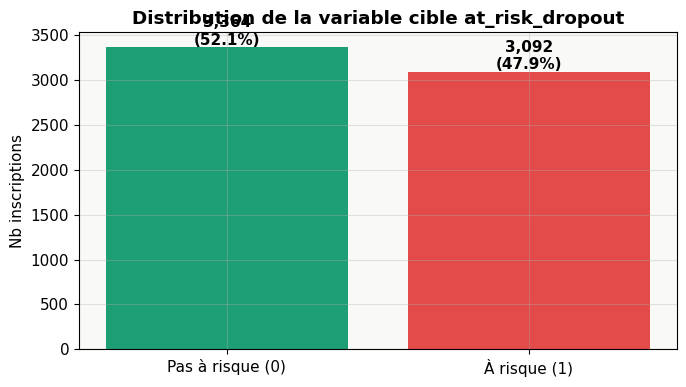

✅ Sauvegardé : ./outputs/at_risk_distribution.png


In [9]:
cond1 = df_inscr['statut'] == 'Abandonne'
cond2 = (
    (df_inscr['nb_jours_inactif'] > 21) &
    (df_inscr['progression_pct'] < 80) &
    (df_inscr['statut'] != 'Termine')
)

df_inscr['at_risk_dropout'] = (cond1 | cond2).astype(int)

print('Distribution at_risk_dropout :')
print(df_inscr['at_risk_dropout'].value_counts())
print(f"\nTaux at_risk (classe positive) : {df_inscr['at_risk_dropout'].mean()*100:.1f}%")

# Visualisation
fig, ax = plt.subplots(figsize=(7, 4))
counts = df_inscr['at_risk_dropout'].value_counts()
bars = ax.bar(['Pas à risque (0)', 'À risque (1)'], counts.values,
              color=[COLORS['secondary'], COLORS['danger']])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df_inscr)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribution de la variable cible at_risk_dropout', fontweight='bold')
ax.set_ylabel('Nb inscriptions')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}at_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Sauvegardé : {SAVE_PATH}at_risk_distribution.png')

> **INTERPRÉTATION :**
> - **3 092 inscriptions à risque** (47.9%) et **3 364 sans risque** (52.1%)
> - Le dataset est **quasi-équilibré** — situation favorable pour le ML, pas besoin de sur-échantillonnage (SMOTE)
> - Le taux de 47.9% peut sembler élevé, mais la définition inclut les Abandonnés ET les inactifs prolongés
>
> **MÉTIER :** Près de 48% des inscriptions sont en situation de risque — alarmant pour la direction d'EduTrack. Sur 4 500 apprenants, ~2 200 sont potentiellement en train de décrocher. Un système d'alerte capable de les identifier 3-4 semaines avant l'abandon permettrait de les ré-engager par email, appel, ou contenu bonus.

---
## Étape 6 — Export de la table analytique

### MÉTHODE
On sélectionne uniquement les colonnes nécessaires pour le ML et le dashboard. Les colonnes brutes redondantes (`date_fin_reelle`, `last_session`) sont exclues pour ne pas créer de **leakage** dans le NB5.

> **Leakage :** une feature qui contient implicitement la réponse à la question qu'on cherche à prédire. Par exemple, inclure `date_fin_reelle` dans les features du modèle serait du leakage car cette date n'existe que pour les apprenants qui ont terminé ou abandonné — le modèle apprendrait à mémoriser, pas à généraliser.

In [10]:
COLS_ANALYTICS = [
    'inscription_id', 'apprenant_id', 'parcours_id', 'date_inscription',
    'statut', 'progression_pct', 'csat', 'jours_depuis_inscription',
    'mois_inscription', 'est_inscription_weekend', 'nb_sessions',
    'duree_totale_min', 'nb_semaines_actives', 'engagement_score',
    'nb_jours_inactif', 'at_risk_dropout'
]

df_analytics = df_inscr[COLS_ANALYTICS].copy()
df_analytics.to_csv(f'{SAVE_PATH}inscriptions_analytics.csv', index=False)

print(f'✅ inscriptions_analytics.csv exporté')
print(f'   Dimensions     : {df_analytics.shape}')
print(f'   Nulls restants : {df_analytics.isnull().sum().sum()}')
print(f'   Localisation   : {SAVE_PATH}')
print(f'\nAperçu :')
print(df_analytics.head(3).to_string())

✅ inscriptions_analytics.csv exporté
   Dimensions     : (6456, 16)
   Nulls restants : 4303
   Localisation   : ./outputs/

Aperçu :
  inscription_id apprenant_id parcours_id date_inscription    statut  progression_pct  csat  jours_depuis_inscription  mois_inscription  est_inscription_weekend  nb_sessions  duree_totale_min  nb_semaines_actives  engagement_score  nb_jours_inactif  at_risk_dropout
0       INS00001      APP0001      PAR011       2022-01-13   Termine           100.00  3.00                       899                 1                        0         0.00              0.00                 0.00              0.00            899.00                0
1       INS00002      APP0001      PAR005       2022-01-13  En cours            73.00   NaN                       899                 1                        0         0.00              0.00                 0.00              0.00            899.00                1
2       INS00003      APP0002      PAR005       2022-03-01   Termine

---
## Bilan du Notebook 2

| Action | Lignes | Impact |
|---|---|---|
| Doublons email supprimés | 3 | df_app : 4 500 → 4 497 |
| Âges aberrants corrigés | 5 | Imputation par médiane (27 ans) |
| Pays null remplis | 2 | 'Non renseigné' |
| Progressions plafonnées | 4 | 100% maximum |
| Sessions supprimées | 67 | 57 075 → 57 008 |
| Paiements négatifs supprimés | 3 | 8 703 → 8 700 |
| **Taux at_risk_dropout** | **47.9%** | **3 092 / 6 456** |

**Fichier exporté :** `inscriptions_analytics.csv` (6 456 lignes × 16 colonnes) — disponible dans `SAVE_PATH`

| Feature | Type | Rôle ML |
|---|---|---|
| `engagement_score` | Float 0-100 | Feature composite (fréquence + durée + régularité) |
| `nb_jours_inactif` | Int | Feature la plus prédictive du décrochage |
| `at_risk_dropout` | Binaire 0/1 | **Variable cible** du modèle ML |

**Pour le NB3 :** Utiliser `inscriptions_analytics.csv` avec DuckDB pour les analyses SQL et les KPIs de performance.

---

**DataProjectLab** — apprendre la data sur des cas concrets, structurés et orientés métier.